# 1. Loading and Visualising ERA5

**Learning objectives**

By the end of this notebook you will be able to:

- Use `earthkit.data.from_source()` to load meteorological data
- Understand the earthkit **FieldList**: iterate, inspect, select
- Read field metadata, values, and lat/lon coordinates
- Convert to `xarray.Dataset` when array operations are needed
- Visualise with `earthkit.plots` directly from a FieldList

---

## What is ERA5?

ERA5 is ECMWF's fifth-generation global atmospheric reanalysis:

- **~31 km** horizontal resolution (native N320 reduced Gaussian grid)
- **137 vertical levels**, **hourly** time steps, **~240 variables**, 1940–present

Almost every modern ML weather model — GraphCast, Pangu-Weather, FourCastNet, AIFS — was trained on ERA5. Before any pipeline, the first step is: **look at your data**.

## Setup

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp
import os

ekd.settings.set({"cache-policy": "user"})
os.makedirs("data", exist_ok=True)
print("earthkit.data version:", ekd.__version__)

earthkit.data version: 1.0.0rc1


## Loading data with `from_source()`

The central abstraction in earthkit-data is `from_source(source, ...)`. The `source` says *where*; the rest says *what*. All sources return the same FieldList type.

### Option A — sample data (no credentials)

In [ ]:
# DATA: era5-N320-2t-msl-20200101.grib — 2m temperature (2t) and mean sea level pressure (msl)
ds = ekd.from_source("sample", "era5-N320-2t-msl-20200101.grib").to_fieldlist()
print(type(ds))

<class 'earthkit.data.readers.grib.file.GribFieldListInFile'>


### Option B — CDS (requires a CDS API key)

[Register for a CDS API key here](https://cds.climate.copernicus.eu/).

In [9]:
# Uncomment once ~/.cdsapirc is in place.

# ds = ekd.from_source(
#     "cds",
#     "reanalysis-era5-single-levels",
#     request=dict(
#         variable=["2m_temperature", "mean_sea_level_pressure"],
#         product_type="reanalysis",
#         date="2012-05-10",
#         time="12:00",
#         area=[73, -27, 33, 45],   # N, W, S, E
#         format="grib",
#     ),
# )
print("CDS cell skipped — using sample data.")

CDS cell skipped — using sample data.


---

## FieldLists — earthkit's native GRIB representation

Loading GRIB data returns a **FieldList**: an ordered collection of fields, each carrying its GRIB metadata alongside its values.

A FieldList is the right place to stay until you need array operations:

- Every field knows its variable, level, time, units, and grid type
- Values are lazy — not decoded until you ask
- `earthkit.plots` accepts FieldLists directly — no conversion needed to visualise
- `earthkit.geo.regrid` regrids FieldLists directly

Convert to `xarray.Dataset` when you need mathematics, aggregation, or Zarr output.

In [25]:
# A FieldList is iterable — each element is one GRIB field
print(f"Fields: {len(ds)}")

ds.ls()

Fields: 2


,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,2t,1985-12-25 12:00:00,1985-12-25 12:00:00,0 days,0,surface,0,regular_ll
1,msl,1985-12-25 12:00:00,1985-12-25 12:00:00,0 days,0,surface,0,regular_ll


### Inspecting a single field

In [ ]:
f0 = ds[0]   # index into a FieldList like a list
f0.describe()

number_of_values,1038240
array_type,ndarray
array_dtype,float64
variable,2t
units,kelvin
valid_datetime,1985-12-25 12:00:00
base_datetime,1985-12-25 12:00:00
step,0:00:00
level,0
layer,None
level_type,surface


In [29]:
# Values — always a 1-D array over all grid points
vals = f0.values
print(f"Shape: {vals.shape}")
print(f"Range: {vals.min():.2f} – {vals.max():.2f} {f0.metadata('units')}")

# Lat/lon — one pair per grid point, same length as values
lats, lons = f0.geography.latlons()
print(f"Lat range : {lats.min():.1f}° – {lats.max():.1f}°")
print(f"Lon range : {lons.min():.1f}° – {lons.max():.1f}°")

Shape: (1038240,)
Range: 222.21 – 314.17 K
Lat range : -90.0° – 90.0°
Lon range : 0.0° – 359.8°


### Selecting fields

When a FieldList contains multiple variables or time steps, `.sel()` filters by metadata and returns a new FieldList.

In [30]:
# DATA: tuv_pl.grib — temperature (t), u-wind, v-wind on multiple pressure levels
fl_multi = ekd.from_source("sample", "tuv_pl.grib").to_fieldlist()
print(f"Total fields: {len(fl_multi)}")
fl_multi.ls()

Total fields: 18


,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
1,u,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
2,v,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,1000,pressure,0,regular_ll
3,t,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,850,pressure,0,regular_ll
4,u,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,850,pressure,0,regular_ll
5,v,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,850,pressure,0,regular_ll
6,t,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,700,pressure,0,regular_ll
7,u,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,700,pressure,0,regular_ll
8,v,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,700,pressure,0,regular_ll
9,t,2018-08-01 12:00:00,2018-08-01 12:00:00,0 days,500,pressure,0,regular_ll


In [31]:
# Select all temperature fields
fl_t = fl_multi.sel({'parameter.variable': 't'})
print(f"Temperature fields: {len(fl_t)}")

# Select temperature at a single level
fl_t500 = fl_multi.sel({'parameter.variable': 't', 'vertical.level': 500})
print(f"T at 500 hPa: range {fl_t500[0].values.min():.1f} – {fl_t500[0].values.max():.1f} K")

Temperature fields: 6
T at 500 hPa: range 227.8 – 271.8 K


### Converting to xarray

Convert to `xarray.Dataset` for array operations, normalisation, aggregation, or Zarr output.

In [32]:
xr_ds = ds.to_xarray()
print(xr_ds)
print()
for var in xr_ds.data_vars:
    da = xr_ds[var]
    print(f"  {var}: shape={da.shape}  "
          f"range [{float(da.min()):.1f}, {float(da.max()):.1f}]  "
          f"units={da.attrs.get('units', '?')}")

<xarray.Dataset> Size: 17MB
Dimensions:    (latitude: 721, longitude: 1440)
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    2t         (latitude, longitude) float64 8MB ...
    msl        (latitude, longitude) float64 8MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

  2t: shape=(721, 1440)  range [222.2, 314.2]  units=kelvin
  msl: shape=(721, 1440)  range [94470.2, 104992.2]  units=pascal


---

## Visualisation with earthkit.plots

`earthkit.plots` reads CF metadata for automatic titles, units, and colour scales. It accepts both FieldLists and xarray DataArrays.

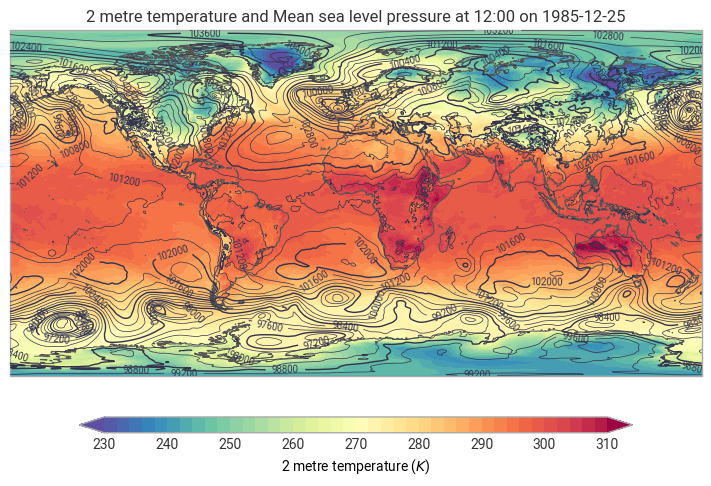

In [33]:
# Plot directly from the FieldList
ekp.quickplot(ds, mode = 'overlay');

---

## Other data sources

All backends return a FieldList. The rest of your pipeline never changes.

```python
ekd.from_source("file", "/path/to/data.grib")                         # local file
ekd.from_source("url",  "https://example.com/data.grib")              # public URL
ekd.from_source("s3",   "s3://my-bucket/data.grib")                   # object store
ekd.from_source("fdb",  request={...})                                # ECMWF FDB
ekd.from_source("polytope", request={...}, address="https://...")     # DestinE
```

Notebook 7 covers Polytope in depth.

---

> **Activity**
>
> 1. Select u-wind fields from `fl_multi` with `.sel()`. Print their levels and value ranges.
> 2. What `gridType` does `tuv_pl.grib` have? Is it the same as `test.grib`?
> 3. Visualise temperature at 500 hPa with `ekp.Figure`.
>
> ```python
> fl_u = fl_multi.sel(shortName="u")
> for f in fl_u:
>     print(f.metadata("level"), f.values.min(), f.values.max())
> ```